<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/KONSTANTA_PLANCK_MP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Data potensial penghenti pada variasi panjang gelombang
data = {
    'Panjang Gelombang': [400, 450, 500, 550, 600, 650],
    'V 1': [1.468, 1.118, 0.878, 0.668, 0.490, 0.320],
    'V 2': [1.396, 1.118, 0.868, 0.670, 0.480, 0.294],
    'V 3': [1.394, 1.116, 0.878, 0.680, 0.498, 0.346],
    'V 4': [1.412, 1.118, 0.878, 0.678, 0.506, 0.358],
    'V 5': [1.328, 1.126, 0.870, 0.678, 0.506, 0.348]
}

# Membuat DataFrame
df = pd.DataFrame(data)

# Mengubah nilai negatif menjadi positif
for col in df.columns[1:]:
    df[col] = df[col].abs()

# Menampilkan tabel
print(df)


   Panjang Gelombang    V 1    V 2    V 3    V 4    V 5
0                400  1.468  1.396  1.394  1.412  1.328
1                450  1.118  1.118  1.116  1.118  1.126
2                500  0.878  0.868  0.878  0.878  0.870
3                550  0.668  0.670  0.680  0.678  0.678
4                600  0.490  0.480  0.498  0.506  0.506
5                650  0.320  0.294  0.346  0.358  0.348


In [ ]:
import pandas as pd

# Data potensial penghenti pada variasi panjang gelombang
data = {
    'Panjang Gelombang': [400, 450, 500, 550, 600, 650],
    'V 1': [1.468, 1.118, 0.878, 0.668, 0.490, 0.320],
    'V 2': [1.396, 1.118, 0.868, 0.670, 0.480, 0.294],
    'V 3': [1.394, 1.116, 0.878, 0.680, 0.498, 0.346],
    'V 4': [1.412, 1.118, 0.878, 0.678, 0.506, 0.358],
    'V 5': [1.328, 1.126, 0.870, 0.678, 0.506, 0.348]
}

# Membuat DataFrame
df = pd.DataFrame(data)

# Mengubah nilai negatif menjadi positif
for col in df.columns[1:]:
    df[col] = df[col].abs()

# Kecepatan cahaya dalam meter per detik
c = 3e8

# Menghitung frekuensi dan mengganti kolom 'Panjang Gelombang'
df['Panjang Gelombang'] = c / df['Panjang Gelombang']* 1e-9
df.rename(columns={'Panjang Gelombang': 'Frekuensi'}, inplace=True)

# Menampilkan tabel
print(df)


   Frekuensi    V 1    V 2    V 3    V 4    V 5
0   0.000750  1.468  1.396  1.394  1.412  1.328
1   0.000667  1.118  1.118  1.116  1.118  1.126
2   0.000600  0.878  0.868  0.878  0.878  0.870
3   0.000545  0.668  0.670  0.680  0.678  0.678
4   0.000500  0.490  0.480  0.498  0.506  0.506
5   0.000462  0.320  0.294  0.346  0.358  0.348


In [ ]:
import pandas as pd
import numpy as np

# Data potensial penghenti pada variasi panjang gelombang (dalam nm)
data = {
    'Panjang Gelombang (nm)': [400, 450, 500, 550, 600, 650],
    'h 1': [1.468, 1.118, 0.878, 0.668, 0.490, 0.320],
    'h 2': [1.396, 1.118, 0.868, 0.670, 0.480, 0.294],
    'h 3': [1.394, 1.116, 0.878, 0.680, 0.498, 0.346],
    'h 4': [1.412, 1.118, 0.878, 0.678, 0.506, 0.358],
    'h 5': [1.328, 1.126, 0.870, 0.678, 0.506, 0.348]
}

# Membuat DataFrame
df = pd.DataFrame(data)

# Konstanta dan variabel fisika
c = 3e8  # kecepatan cahaya (m/s)
e = 1.602176634e-19  # muatan elektron (C)
W0 = 2.23e-19  # fungsi kerja bahan (Joule)
h_teori = 6.62607015e-34  # konstanta Planck teori (J.s)

# Mengubah nilai negatif menjadi positif
for col in df.columns[1:]:
    df[col] = df[col].abs()

# Menghitung frekuensi dari panjang gelombang (Hz)
df['Frekuensi (Hz)'] = c / (df['Panjang Gelombang (nm)'] * 1e-9)

# Fungsi untuk menghitung konstanta Planck h
def hitung_h(V, lam_m):
    return ((e * V) + W0) * lam_m / c

# DataFrame untuk hasil h dan error
h_values = pd.DataFrame()
h_values['Frekuensi (Hz)'] = df['Frekuensi (Hz)']
h_errors = pd.DataFrame()
h_errors['Frekuensi (Hz)'] = df['Frekuensi (Hz)']

# Hitung h dan error dalam persen untuk setiap kolom h1 sampai h5
for col in df.columns[1:-1]:
    h_list = []
    error_list = []
    for i, V in enumerate(df[col]):
        lam = df.loc[i, 'Panjang Gelombang (nm)'] * 1e-9
        h_val = hitung_h(V, lam)
        h_list.append(h_val)
        error = abs(h_val - h_teori) / h_teori * 100  # persen
        error_list.append(error)
    h_values[col] = h_list
    h_errors[col + ' Error (%)'] = error_list

# Gabungkan hasil h dan error ke satu DataFrame
h_result = pd.concat([h_values, h_errors.drop(columns=['Frekuensi (Hz)'])], axis=1)

# Format tampilan angka dengan 3 desimal
pd.options.display.float_format = '{:.3e}'.format

print(h_result)


   Frekuensi (Hz)       h 1       h 2       h 3       h 4       h 5  \
0       7.500e+14 6.109e-34 5.956e-34 5.951e-34 5.990e-34 5.810e-34   
1       6.667e+14 6.032e-34 6.032e-34 6.027e-34 6.032e-34 6.051e-34   
2       6.000e+14 6.061e-34 6.034e-34 6.061e-34 6.061e-34 6.040e-34   
3       5.455e+14 6.050e-34 6.056e-34 6.086e-34 6.080e-34 6.080e-34   
4       5.000e+14 6.030e-34 5.998e-34 6.056e-34 6.081e-34 6.081e-34   
5       4.615e+14 5.943e-34 5.852e-34 6.033e-34 6.074e-34 6.040e-34   

   h 1 Error (%)  h 2 Error (%)  h 3 Error (%)  h 4 Error (%)  h 5 Error (%)  
0      7.799e+00      1.012e+01      1.018e+01      9.604e+00      1.231e+01  
1      8.968e+00      8.968e+00      9.040e+00      8.968e+00      8.678e+00  
2      8.525e+00      8.928e+00      8.525e+00      8.525e+00      8.848e+00  
3      8.687e+00      8.598e+00      8.155e+00      8.244e+00      8.244e+00  
4      8.994e+00      9.477e+00      8.607e+00      8.220e+00      8.220e+00  
5      1.032e+01      1.168e

In [ ]:
# Data nilai h (Joule detik) berdasarkan gambar terbaru
h_data = {
    'h1': [6.109e-34, 6.032e-34, 6.061e-34, 6.050e-34, 6.030e-34, 5.943e-34],
    'h2': [5.956e-34, 6.032e-34, 6.034e-34, 6.056e-34, 5.998e-34, 5.852e-34],
    'h3': [5.951e-34, 6.027e-34, 6.061e-34, 6.086e-34, 6.056e-34, 6.033e-34],
    'h4': [5.990e-34, 6.032e-34, 6.061e-34, 6.080e-34, 6.081e-34, 6.074e-34],
    'h5': [5.810e-34, 6.051e-34, 6.040e-34, 6.080e-34, 6.081e-34, 6.040e-34]
}

# Fungsi untuk menghitung standar deviasi
def hitung_standar_deviasi(data):
    n = len(data)
    mean = sum(data) / n
    jumlah_kuadrat_selisih = sum((x - mean) ** 2 for x in data)
    return (jumlah_kuadrat_selisih / (n - 1)) ** 0.5

# Tampilkan standar deviasi per kolom
for key, values in h_data.items():
    std_dev = hitung_standar_deviasi(values)
    print(f"Standar deviasi {key}: {std_dev:.3e} J·s")


Standar deviasi h1: 5.447e-36 J·s
Standar deviasi h2: 7.523e-36 J·s
Standar deviasi h3: 4.656e-36 J·s
Standar deviasi h4: 3.586e-36 J·s
Standar deviasi h5: 1.031e-35 J·s


Saving Untitled spreadsheet.xlsx to Untitled spreadsheet (4).xlsx


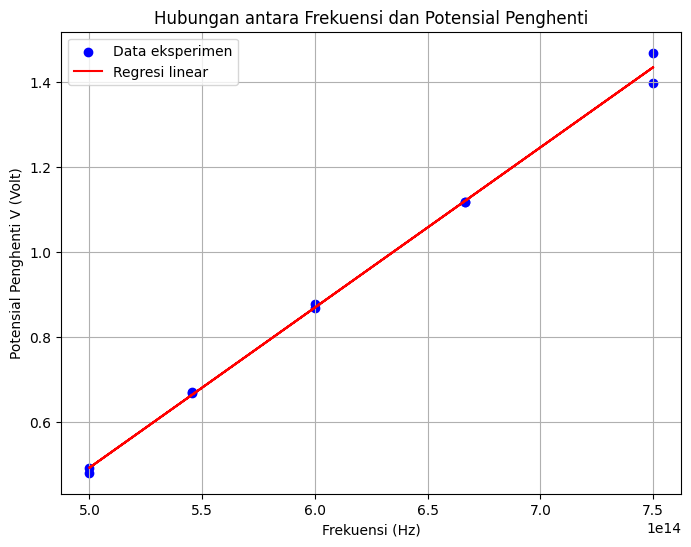

Kemiringan (h/e) ≈ 3.77e-15 V·s
Intersep (-W/e) ≈ -1.39 V


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from google.colab import files

# Unggah file terlebih dahulu
uploaded = files.upload()

# Ambil nama file yang diunggah
file_path = list(uploaded.keys())[0]

# Konstanta
c = 3e8  # kecepatan cahaya (m/s)
e = 1.602e-19  # muatan elektron (C)

# Membaca data mentah dari file
df_raw = pd.read_excel(file_path, header=None)

# Mengambil data sesi 1 dan sesi 2 secara manual berdasarkan posisi
sesi1 = df_raw.iloc[3:9, 1:3].copy()  # baris 4-9, kolom panjang gelombang dan Vo
sesi2 = df_raw.iloc[3:9, 6:8].copy()  # baris 4-9, kolom panjang gelombang dan Vo sesi 2

sesi1.columns = ['lambda', 'V']
sesi2.columns = ['lambda', 'V']

# Gabungkan dua sesi
data = pd.concat([sesi1, sesi2], ignore_index=True)

# Hapus baris yang mengandung NaN (jika ada)
data.dropna(inplace=True)

# Hapus baris yang kolom 'lambda' atau 'V' mengandung teks non-numerik
data = data[data['lambda'].apply(lambda x: str(x).replace('.', '', 1).isdigit())]
data = data[data['V'].apply(lambda x: str(x).replace('.', '', 1).replace('-', '', 1).isdigit())]

# Ubah panjang gelombang dari nm ke meter
data['lambda'] = data['lambda'].astype(float)
data['V'] = data['V'].astype(float)
data['lambda_m'] = data['lambda'] * 1e-9

# Hitung frekuensi: f = c / lambda
data['f'] = c / data['lambda_m']

# Regresi linear V vs f
X = data['f'].values.reshape(-1, 1)
y = data['V'].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]  # mendekati h/e
intercept = model.intercept_  # mendekati -W/e

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(data['f'], data['V'], color='blue', label='Data eksperimen')
plt.plot(data['f'], model.predict(X), color='red', label='Regresi linear')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Potensial Penghenti V (Volt)')
plt.title('Hubungan antara Frekuensi dan Potensial Penghenti')
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan hasil regresi
print(f"Kemiringan (h/e) ≈ {slope:.2e} V·s")
print(f"Intersep (-W/e) ≈ {intercept:.2f} V")

Saving Untitled spreadsheet.xlsx to Untitled spreadsheet (6).xlsx


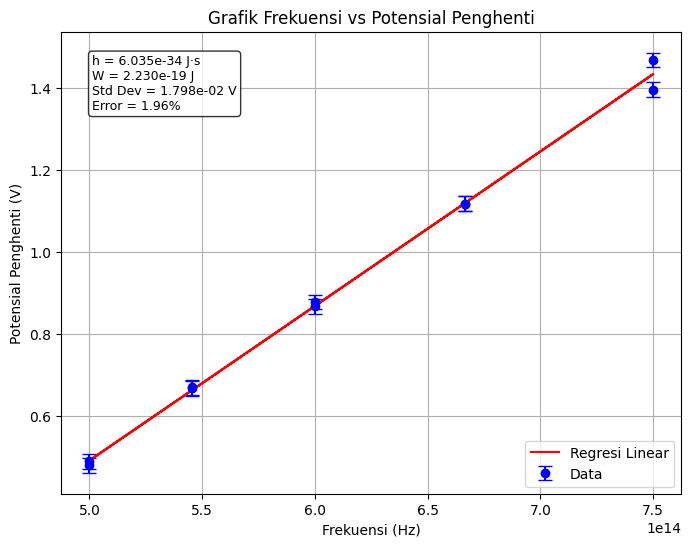

Konstanta Planck (h) ≈ 6.035e-34 J·s
Fungsi kerja logam (W) ≈ 2.230e-19 J
Deviasi standar data ≈ 1.798e-02 V
Galat relatif data ≈ 1.96%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from google.colab import files

# Upload file
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# Konstanta
c = 3e8  # m/s
e = 1.602e-19  # C

# Baca Excel
df_raw = pd.read_excel(file_path, header=None)

# Ambil data Sesi 1 dan Sesi 2 secara eksplisit
sesi1 = df_raw.iloc[3:9, [1, 2]].copy()  # Kolom 1 = λ, 2 = V
sesi2 = df_raw.iloc[3:9, [6, 7]].copy()  # Kolom 6 = λ, 7 = V

# Beri nama kolom
sesi1.columns = ['lambda', 'V']
sesi2.columns = ['lambda', 'V']

# Gabungkan dan bersihkan
data = pd.concat([sesi1, sesi2], ignore_index=True)
data.dropna(inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')
data.dropna(inplace=True)

# Konversi satuan
data['lambda_m'] = data['lambda'] * 1e-9  # dari nm ke m
data['f'] = c / data['lambda_m']         # frekuensi f = c / λ

# Regresi linear
X = data['f'].values.reshape(-1, 1)
y = data['V'].values

model = LinearRegression()
model.fit(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# Hitung nilai fisika
h = slope * e
W = -intercept * e

# Residuals dan deviasi
predicted_V = model.predict(X)
residuals = y - predicted_V
std_dev = np.std(residuals, ddof=1)
percent_error = (std_dev / np.mean(y)) * 100

# Plot
plt.figure(figsize=(8, 6))
plt.errorbar(data['f'], data['V'], yerr=std_dev, fmt='o', color='blue', label='Data', capsize=5)
plt.plot(data['f'], predicted_V, color='red', label='Regresi Linear')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Potensial Penghenti (V)')
plt.title('Grafik Frekuensi vs Potensial Penghenti')
plt.grid(True)
plt.legend()

# Info di grafik
info = (
    f"h = {h:.3e} J·s\n"
    f"W = {W:.3e} J\n"
    f"Std Dev = {std_dev:.3e} V\n"
    f"Error = {percent_error:.2f}%"
)
plt.text(0.05, 0.95, info, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

plt.show()

# Output numerik
print(f"Konstanta Planck (h) ≈ {h:.3e} J·s")
print(f"Fungsi kerja logam (W) ≈ {W:.3e} J")
print(f"Deviasi standar data ≈ {std_dev:.3e} V")
print(f"Galat relatif data ≈ {percent_error:.2f}%")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00


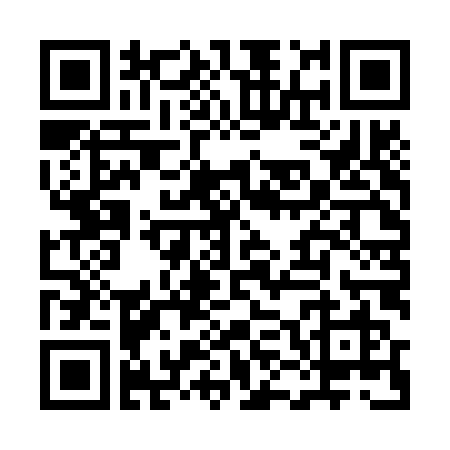

In [ ]:
from re import S
# prompt: coba buat qr code dengan  menyematkan link

!pip install qrcode

import qrcode

# Link yang ingin disematkan dalam QR Code
link = "https://colab.research.google.com/drive/1sggiun-ZwuwboJMi9oQzxnQ-xMXHveNj#scrollTo=XLd2XBIgzOEk"  # Ganti dengan link yang diinginkan

# Membuat objek QR Code
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_L,
    box_size=10,
    border=4,
)

# Menambahkan data (link) ke QR Code
qr.add_data(link)
qr.make(fit=True)

# Membuat gambar QR Code
img = qr.make_image(fill_color="black", back_color="white")

# Menyimpan gambar QR Code
img.save("qrcode_link.png")

display(img)